<a href="https://colab.research.google.com/github/amathie5/projet-breast-cancer/blob/main/datascience_project_breastcancer_v10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [18]:
#CSV files importation
df1 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df1.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df2.csv')
df3 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df3.csv')

#Concatening all dataframes together to be left with one unique dataframe
df = pd.concat([df1,df2,df3]).sort_values(by='year')
df_encoded = df.copy()

#Displaying the head of the dataset
display(df.head())

# Number of variables (columns)
num_variables = df.shape[1]

# Number of observations (lines)
num_observations = df.shape[0]

# Total number of values
total_values = df.size  # équivalent à num_variables * num_observations

# Affichage
print(f'The dataset contains a total of {num_variables} variables and {num_observations} observations, for a total of {total_values} values')
print(f'The dataset contains no null value and every variable is of type int64')
display(df.info())



,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
20,2005,1,1,0,1,0,2,0,1,1,0,0,1
19,2005,1,1,0,0,9,4,0,1,9,9,9,1
18,2005,1,1,0,0,9,4,0,1,1,0,0,1
7,2005,1,1,0,0,4,2,0,1,1,0,0,1
6,2005,1,1,0,0,2,3,0,1,9,0,0,1


The dataset contains a total of 13 variables and 1522340 observations, for a total of 19790420 values
The dataset contains no null value and every variable is of type int64
<class 'pandas.core.frame.DataFrame'>
Index: 1522340 entries, 20 to 411300
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype
---  ------                 --------------    -----
 0   year                   1522340 non-null  int64
 1   age_group_5_years      1522340 non-null  int64
 2   race_eth               1522340 non-null  int64
 3   first_degree_hx        1522340 non-null  int64
 4   age_menarche           1522340 non-null  int64
 5   age_first_birth        1522340 non-null  int64
 6   BIRADS_breast_density  1522340 non-null  int64
 7   current_hrt            1522340 non-null  int64
 8   menopaus               1522340 non-null  int64
 9   bmi_group              1522340 non-null  int64
 10  biophx                 1522340 non-null  int64
 11  breast_cancer_history  1522340 non-nul

None

In [19]:
age_map = {1:'18-29',2:'30-34',3:'35-39',4:'40-44',5:'45-49',6:'50-54',7:'55-59',8:'60-64',9:'65-69',10:'70-74',11:'75-79',12:'80-84',13:'85+'}
race_map = {1:'non-hispanic white', 2:'non-hispanic black', 3:'asian/pacific islander', 4:'native american',5:'hispanic',6:'other/mixed',9:'unknown'}
familyhx_map = {0:'no', 1:'yes', 9:'unknown'}
menarche_map = {0:'14+',1:'12-13',2:'<12',9:'unknown'}
firstbirth_map = {0:'<20',1:'20-24',2:'25-29',3:'30+',4:'nulliparous',9:'unknown'}
BIRADS_map = {1:'fatty',2:'scattered',3:'heterogeneously dense', 4:'extremely dense', 5:'unknown'}
hrt_map = {0:'no', 1:'yes',9:'unknown'}
menopaus_map = {1:'pre-menopausal',2:'post-menopausal',3:'surgical menopause', 9:'unknown'}
bmi_map = {1:'10-24.99',2:'25-29.99',3:'30-34.99',4:'35+',9:'unknown'}
biophx_map = {0:'no',1:'yes', 9:'unknown'}
history_map = {0:'no',1:'yes',9:'unknown'}

#Replacing the code with the categories
df['age_group_5_years']=df['age_group_5_years'].map(age_map)
df['race_eth']=df['race_eth'].map(race_map)
df['first_degree_hx']=df['first_degree_hx'].map(familyhx_map)
df['age_menarche']=df['age_menarche'].map(menarche_map)
df['age_first_birth']=df['age_first_birth'].map(firstbirth_map)
df['BIRADS_breast_density']=df['BIRADS_breast_density'].map(BIRADS_map)
df['current_hrt']=df['current_hrt'].map(hrt_map)
df['menopaus']=df['menopaus'].map(menopaus_map)
df['bmi_group']=df['bmi_group'].map(bmi_map)
df['biophx']=df['biophx'].map(biophx_map)
df['breast_cancer_history']=df['breast_cancer_history'].map(history_map)

#convert as category
cat_cols = ['age_group_5_years','race_eth','first_degree_hx','age_menarche','age_first_birth','BIRADS_breast_density','current_hrt','menopaus','bmi_group','biophx','breast_cancer_history']
df[cat_cols] = df[cat_cols].astype('category')
display(df.head())
df.info()
df.isna().sum()




,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1
19,2005,18-29,non-hispanic white,no,14+,unknown,extremely dense,no,pre-menopausal,unknown,unknown,unknown,1
18,2005,18-29,non-hispanic white,no,14+,unknown,extremely dense,no,pre-menopausal,10-24.99,no,no,1
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1
6,2005,18-29,non-hispanic white,no,14+,25-29,heterogeneously dense,no,pre-menopausal,unknown,no,no,1


<class 'pandas.core.frame.DataFrame'>
Index: 1522340 entries, 20 to 411300
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   year                   1522340 non-null  int64   
 1   age_group_5_years      1522340 non-null  category
 2   race_eth               1522340 non-null  category
 3   first_degree_hx        1522340 non-null  category
 4   age_menarche           1522340 non-null  category
 5   age_first_birth        1522340 non-null  category
 6   BIRADS_breast_density  1343329 non-null  category
 7   current_hrt            1522340 non-null  category
 8   menopaus               1522340 non-null  category
 9   bmi_group              1522340 non-null  category
 10  biophx                 1522340 non-null  category
 11  breast_cancer_history  1522340 non-null  category
 12  count                  1522340 non-null  int64   
dtypes: category(11), int64(2)
memory usage: 50.8 MB


,0
year,0
age_group_5_years,0
race_eth,0
first_degree_hx,0
age_menarche,0
age_first_birth,0
BIRADS_breast_density,179011
current_hrt,0
menopaus,0
bmi_group,0


In [20]:
#replace unknown values by nan
df = df.replace('unknown',np.nan)

#check for duplicates
print(df.duplicated().sum())

#the total number of observations should be 6'788'436
print(df['count'].sum())


/tmp/ipython-input-3569221684.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace('unknown',np.nan)


0
6788436


In [21]:
#create two binary variables for high BIRADS and cancer history
df['BIRADS_high']=np.where(df_encoded['BIRADS_breast_density'].isin([3,4]),1,0)
df['breast_cancer_history_bin']=np.where(df_encoded['breast_cancer_history']==1,1,0)

#check the distribution
display(df['BIRADS_high'])
display(df['breast_cancer_history_bin'])

display(df.head())

,BIRADS_high
20,0
19,1
18,1
7,0
6,1
...,...
411304,1
411303,1
411302,1
411301,1


,breast_cancer_history_bin
20,0
19,0
18,0
7,0
6,0
...,...
411304,0
411303,0
411302,0
411301,0


,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
19,2005,18-29,non-hispanic white,no,14+,NaN,extremely dense,no,pre-menopausal,NaN,NaN,NaN,1,1,0
18,2005,18-29,non-hispanic white,no,14+,NaN,extremely dense,no,pre-menopausal,10-24.99,no,no,1,1,0
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
6,2005,18-29,non-hispanic white,no,14+,25-29,heterogeneously dense,no,pre-menopausal,NaN,no,no,1,1,0


In [22]:
#check types and unique values
for col in cat_cols:
  print(col, ':',df[col].unique())

age_group_5_years : ['18-29', '85+', '30-34', '35-39', '40-44', ..., '60-64', '65-69', '70-74', '75-79', '80-84']
Length: 13
Categories (13, object): ['18-29', '30-34', '35-39', '40-44', ..., '70-74', '75-79', '80-84', '85+']
race_eth : ['non-hispanic white', NaN, 'non-hispanic black', 'asian/pacific islander', 'hispanic', 'native american', 'other/mixed']
Categories (6, object): ['asian/pacific islander', 'hispanic', 'native american', 'non-hispanic black',
                         'non-hispanic white', 'other/mixed']
first_degree_hx : ['no', NaN, 'yes']
Categories (2, object): ['no', 'yes']
age_menarche : ['12-13', '14+', NaN, '<12']
Categories (3, object): ['12-13', '14+', '<12']
age_first_birth : ['<20', NaN, 'nulliparous', '25-29', '20-24', '30+']
Categories (5, object): ['20-24', '25-29', '30+', '<20', 'nulliparous']
BIRADS_breast_density : ['scattered', 'extremely dense', 'heterogeneously dense', NaN, 'fatty']
Categories (4, object): ['extremely dense', 'fatty', 'heterogeneously

In [23]:
df_cleaned = df.dropna()
df_cleaned.info()
display(df_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 345064 entries, 20 to 411300
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   year                       345064 non-null  int64   
 1   age_group_5_years          345064 non-null  category
 2   race_eth                   345064 non-null  category
 3   first_degree_hx            345064 non-null  category
 4   age_menarche               345064 non-null  category
 5   age_first_birth            345064 non-null  category
 6   BIRADS_breast_density      345064 non-null  category
 7   current_hrt                345064 non-null  category
 8   menopaus                   345064 non-null  category
 9   bmi_group                  345064 non-null  category
 10  biophx                     345064 non-null  category
 11  breast_cancer_history      345064 non-null  category
 12  count                      345064 non-null  int64   
 13  BIRADS_high       

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
4,2005,18-29,non-hispanic white,no,14+,20-24,extremely dense,no,pre-menopausal,35+,no,no,1,1,0
2,2005,18-29,non-hispanic white,no,14+,<20,extremely dense,no,pre-menopausal,25-29.99,no,no,1,1,0
51,2005,18-29,non-hispanic white,no,<12,<20,scattered,no,pre-menopausal,30-34.99,no,no,1,0,0


In [24]:

df_cleaned.describe(include = 'all')

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
count,345064.000000,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064.000000,345064.000000,345064.000000
unique,NaN,13,6,2,3,5,4,2,3,4,2,2,NaN,NaN,NaN
top,NaN,50-54,non-hispanic white,no,12-13,20-24,scattered,no,post-menopausal,10-24.99,no,no,NaN,NaN,NaN
freq,NaN,55940,160707,244775,146835,80181,128616,324839,203441,105624,211903,292132,NaN,NaN,NaN
mean,2011.492807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.024227,0.491874,0.153398
std,3.708228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.468720,0.499935,0.360371
min,2005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
25%,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
50%,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
75%,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,0.000000


Certaines combinaisons reviennent très fréquemment (1093 fois) alors que certains ne sont présente que une fois. En moyenne les combinaisons apparaissent 5,5 fois.
En moyenne 47,75% des femmes ont une densité mammaire élevée et 16,42% ont été diagnostiquées avec un cancer dans le passé.

/tmp/ipython-input-3903171343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cleaned_agg = df_cleaned.groupby(cat_cols, as_index=False)['count'].sum()


,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
0,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,no,no,0
1,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,no,yes,0
2,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,yes,no,0
3,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,10-24.99,yes,yes,0
4,18-29,asian/pacific islander,no,12-13,20-24,extremely dense,no,post-menopausal,25-29.99,no,no,0


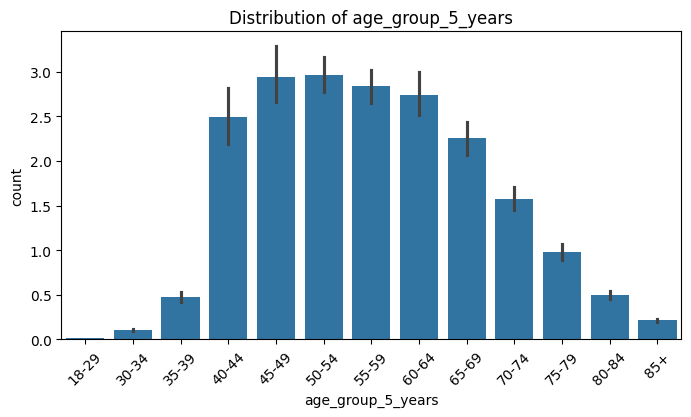

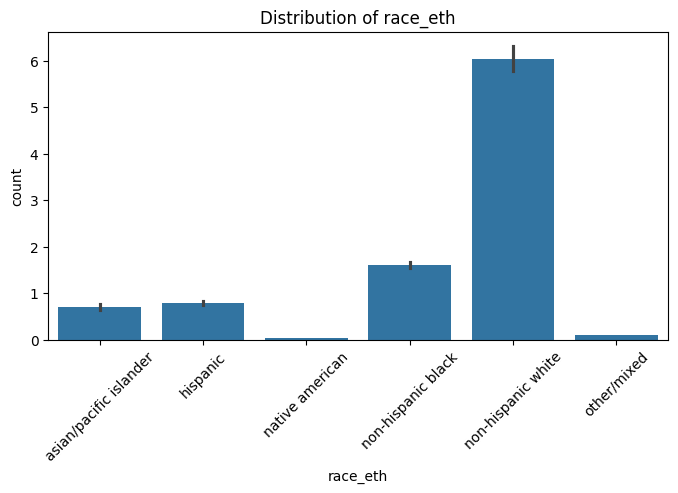

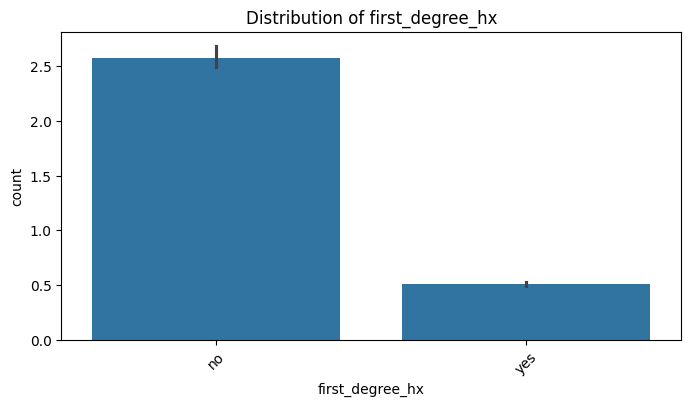

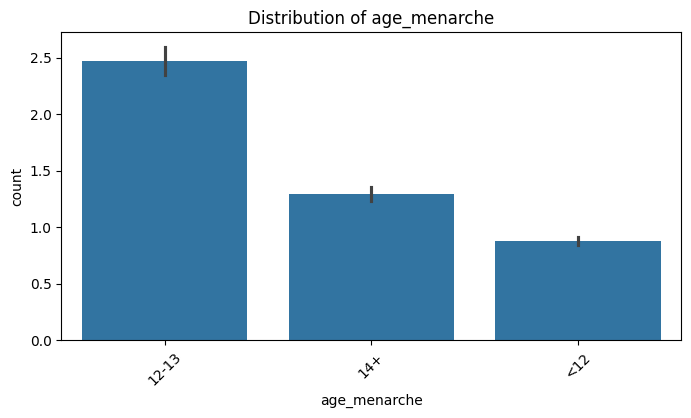

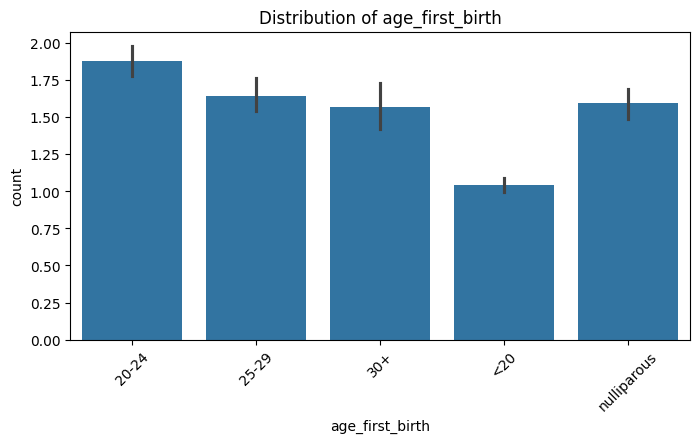

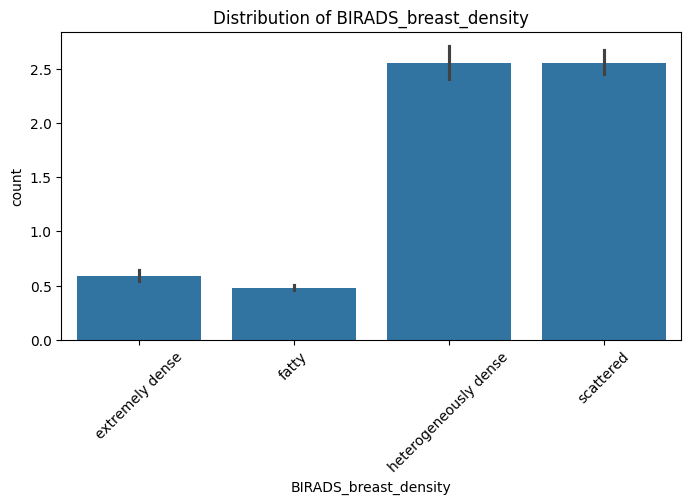

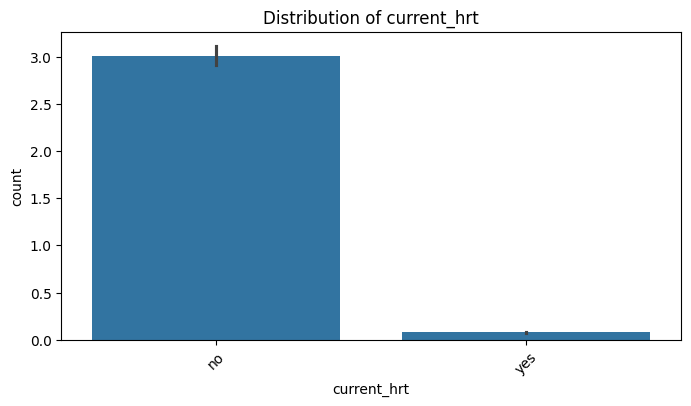

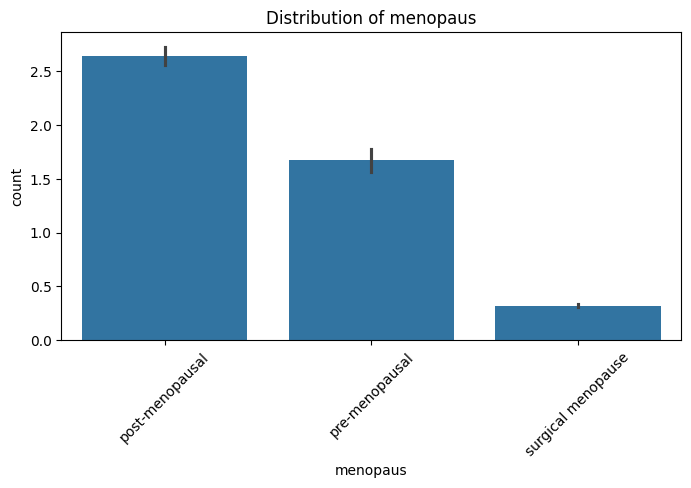

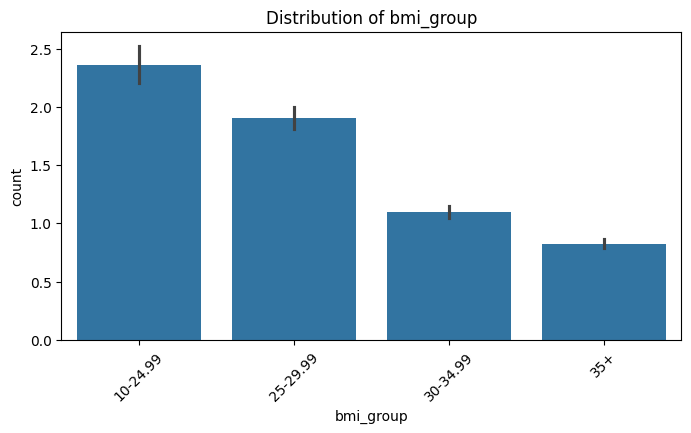

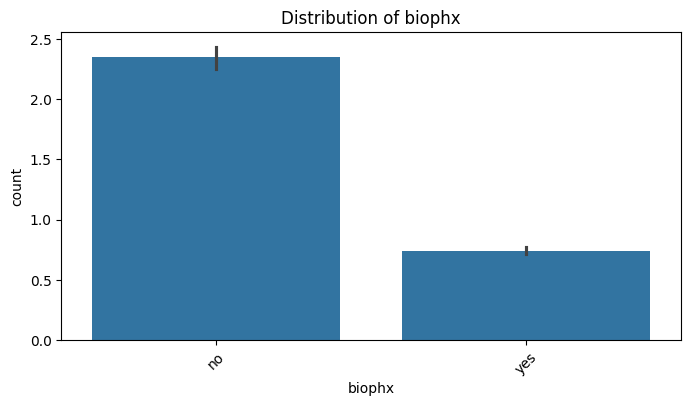

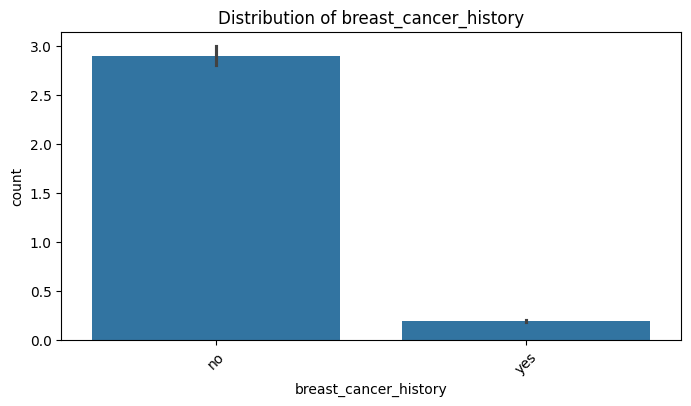

In [25]:
df_cleaned_agg = df_cleaned.groupby(cat_cols, as_index=False)['count'].sum()
display(df_cleaned_agg.head())

for var in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(data=df_cleaned_agg, x=var, y='count')
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {var}')
    plt.show()



Distribution de base, observer s'il y a des catégories qui dominent ou des déséquilibres (beaucoup de femmes post ménopausées,...)

In [26]:
#calcul proportion femme avec densité mammaire élevée et proportion femme avec un antécédent de cancer
p_birads_high = (df_cleaned['BIRADS_high'] * df_cleaned['count']).sum() / df_cleaned['count'].sum()
p_history = (df_cleaned['breast_cancer_history_bin'] * df_cleaned['count']).sum() / df_cleaned['count'].sum()
print(f'Proportion with high breast density : {p_birads_high:.2%}')
print(f'Proportion with prior breast cancer : {p_history:.2%}')

Proportion with high breast density : 50.89%
Proportion with prior breast cancer : 6.18%


/tmp/ipython-input-4224989659.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_age = df_cleaned.groupby('age_group_5_years').apply(
/tmp/ipython-input-4224989659.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot_age = df_cleaned.groupby('age_group_5_years').apply(
/tmp/ipython-input-4224989659.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

<function matplotlib.pyplot.show(close=None, block=None)>

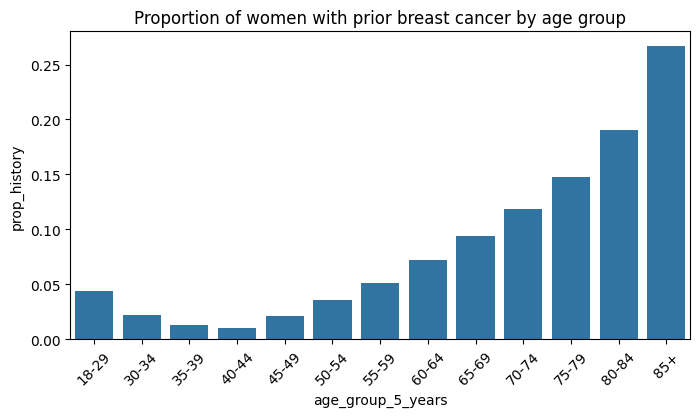

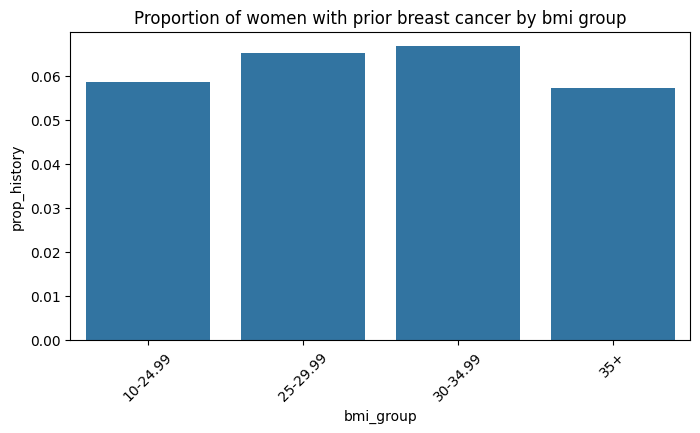

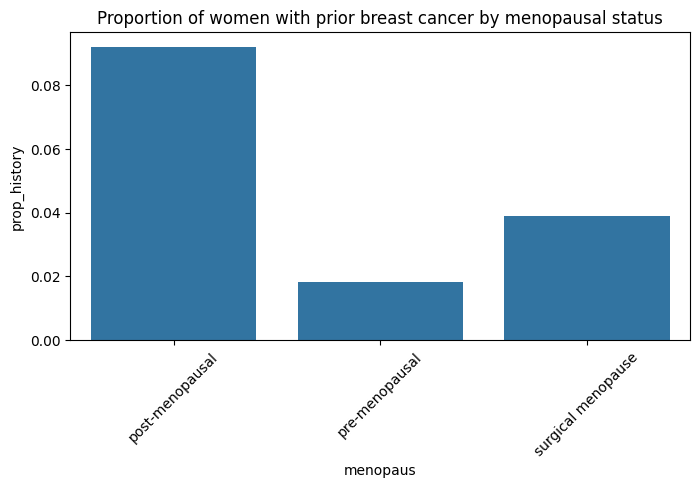

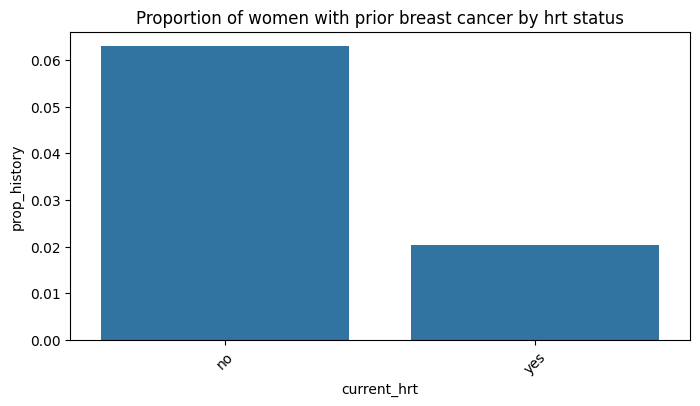

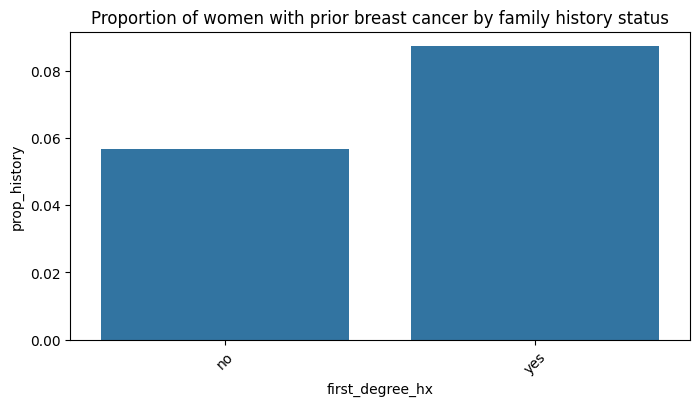

In [27]:
#Maintenant on veut voir comment les variables explicatives influencent les deux variables cibles (breast_cancer_hisotry et BIRADS_high)
#on peut regarder par exemple, comment l'âge influence la breast_cancer_history
pivot_age = df_cleaned.groupby('age_group_5_years').apply(
    lambda x: (x['breast_cancer_history_bin']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_age, x='age_group_5_years',y='prop_history')
plt.xticks(rotation=45)
plt.title('Proportion of women with prior breast cancer by age group')
plt.show

#on reproduit ça avec des autres variables
pivot_bmi = df_cleaned.groupby('bmi_group').apply(
    lambda x: (x['breast_cancer_history_bin']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_bmi, x='bmi_group',y='prop_history')
plt.xticks(rotation=45)
plt.title('Proportion of women with prior breast cancer by bmi group')
plt.show

pivot_menopaus = df_cleaned.groupby('menopaus').apply(
    lambda x: (x['breast_cancer_history_bin']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_menopaus, x='menopaus',y='prop_history')
plt.xticks(rotation=45)
plt.title('Proportion of women with prior breast cancer by menopausal status')
plt.show

pivot_hrt = df_cleaned.groupby('current_hrt').apply(
    lambda x: (x['breast_cancer_history_bin']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_hrt, x='current_hrt',y='prop_history')
plt.xticks(rotation=45)
plt.title('Proportion of women with prior breast cancer by hrt status')
plt.show

pivot_family = df_cleaned.groupby('first_degree_hx').apply(
    lambda x: (x['breast_cancer_history_bin']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_family, x='first_degree_hx',y='prop_history')
plt.xticks(rotation=45)
plt.title('Proportion of women with prior breast cancer by family history status')
plt.show

/tmp/ipython-input-2620910969.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_age_BIRADS = df_cleaned.groupby('age_group_5_years').apply(
/tmp/ipython-input-2620910969.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot_age_BIRADS = df_cleaned.groupby('age_group_5_years').apply(
/tmp/ipython-input-2620910969.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

<function matplotlib.pyplot.show(close=None, block=None)>

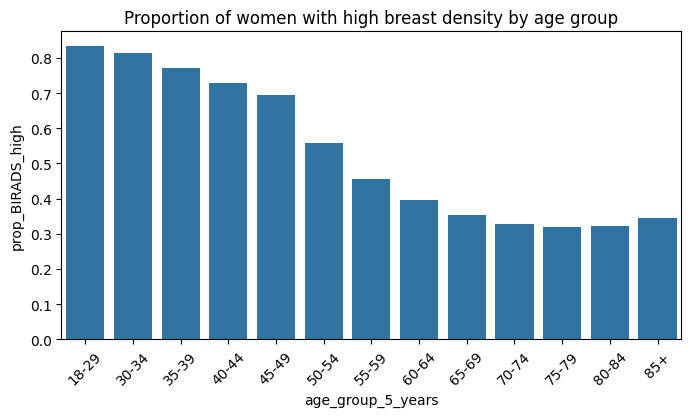

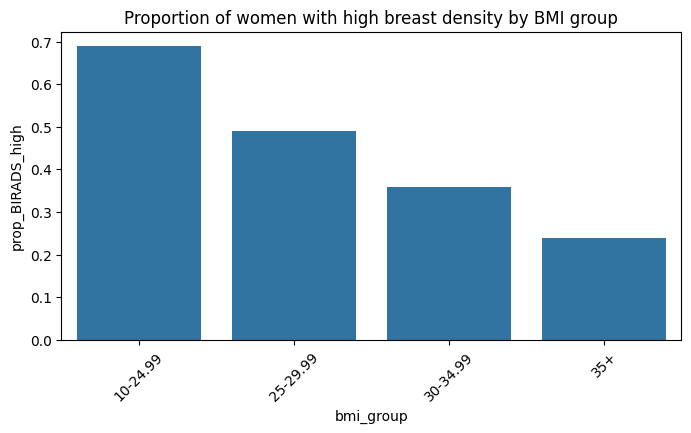

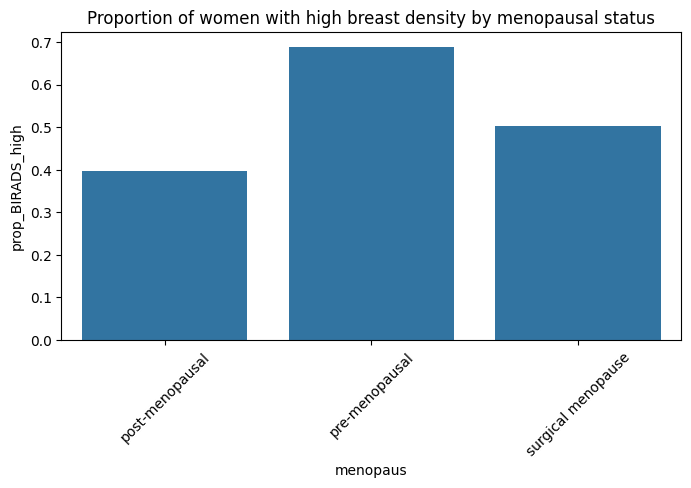

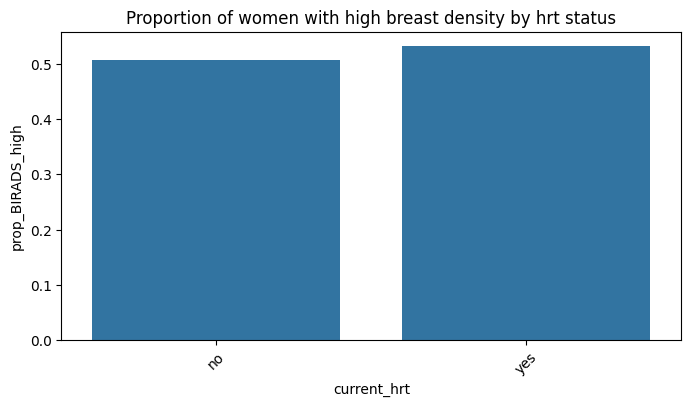

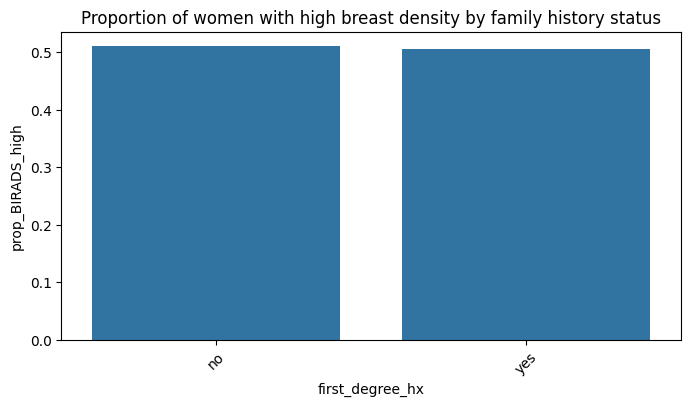

In [28]:
#on fait pareil pour regarder l'influence des variables sur BIRADS_high
pivot_age_BIRADS = df_cleaned.groupby('age_group_5_years').apply(
    lambda x: (x['BIRADS_high']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_BIRADS_high')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_age_BIRADS, x='age_group_5_years',y='prop_BIRADS_high')
plt.xticks(rotation=45)
plt.title('Proportion of women with high breast density by age group')
plt.show

pivot_bmi_BIRADS = df_cleaned.groupby('bmi_group').apply(
    lambda x: (x['BIRADS_high']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_BIRADS_high')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_bmi_BIRADS, x='bmi_group',y='prop_BIRADS_high')
plt.xticks(rotation=45)
plt.title('Proportion of women with high breast density by BMI group')
plt.show

pivot_menopaus_BIRADS = df_cleaned.groupby('menopaus').apply(
    lambda x: (x['BIRADS_high']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_BIRADS_high')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_menopaus_BIRADS, x='menopaus',y='prop_BIRADS_high')
plt.xticks(rotation=45)
plt.title('Proportion of women with high breast density by menopausal status')
plt.show

pivot_hrt_BIRADS = df_cleaned.groupby('current_hrt').apply(
    lambda x: (x['BIRADS_high']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_BIRADS_high')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_hrt_BIRADS, x='current_hrt',y='prop_BIRADS_high')
plt.xticks(rotation=45)
plt.title('Proportion of women with high breast density by hrt status')
plt.show

pivot_family_BIRADS = df_cleaned.groupby('first_degree_hx').apply(
    lambda x: (x['BIRADS_high']*x['count']).sum() / x['count'].sum()
).reset_index(name='prop_BIRADS_high')

plt.figure(figsize=(8,4))
sns.barplot(data=pivot_family_BIRADS, x='first_degree_hx',y='prop_BIRADS_high')
plt.xticks(rotation=45)
plt.title('Proportion of women with high breast density by family history status')
plt.show

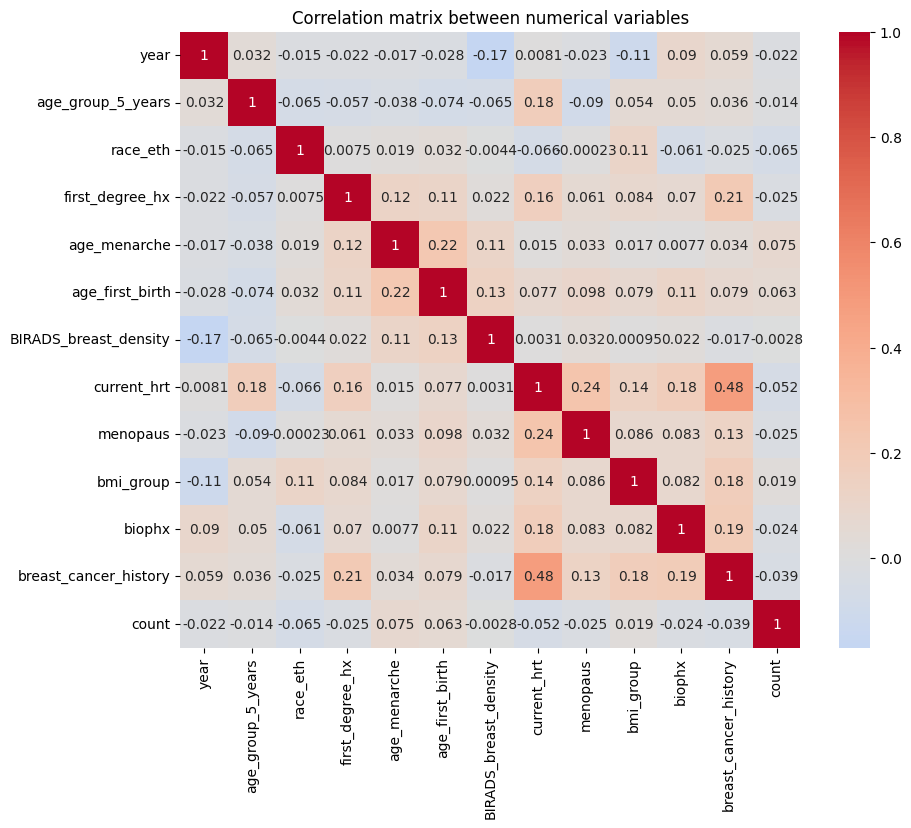

In [29]:
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix between numerical variables')
plt.show()

Corrélations globalement faibles => pas de multicolinéarité forte entre les variables encodées, donc on peut utiliser ces variables pour faire des régressions

corrélations à noter :

*   current_hrt et menopaus : l'hormonothérapie est liée à la ménopause
*   current_hrt et breast_cancer_history : assez élevé, certaines femmes ayant eu un cancer ont pu suivre un traitement hormonal
*  first_degree_hx et breast_cancer_history : antécédents familiaux corrélés aux antécédents personnels
*   age_menarche et age_first_birth : légère corrélation biologique logique






/tmp/ipython-input-168532995.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_BIRADS = df_cleaned.groupby('year').apply(
/tmp/ipython-input-168532995.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_history = df_cleaned.groupby('year').apply(


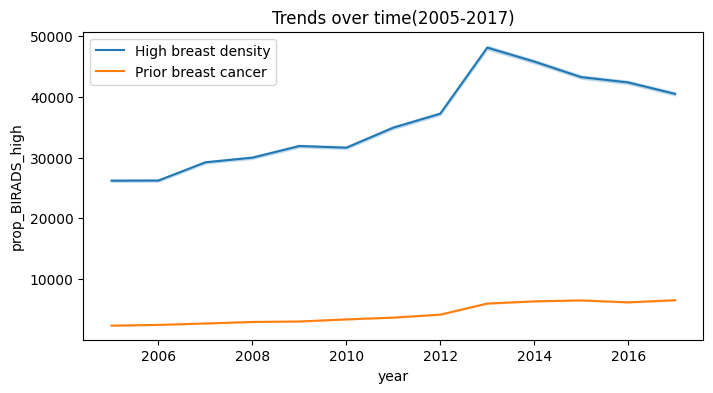

In [30]:
#voir si il y a des tendances dans le temps
trend_BIRADS = df_cleaned.groupby('year').apply(
    lambda x: (x['BIRADS_high'] * x['count']).sum() / x['count']
).reset_index(name='prop_BIRADS_high')

trend_history = df_cleaned.groupby('year').apply(
    lambda x: (x['breast_cancer_history_bin'] * x['count']).sum() / x['count']
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.lineplot(data=trend_BIRADS, x='year',y='prop_BIRADS_high', label = 'High breast density')
sns.lineplot(data=trend_history, x='year', y='prop_history', label = 'Prior breast cancer')
plt.title('Trends over time(2005-2017)')
plt.legend()
plt.show()

In [31]:
from google.colab import files

df_encoded.to_csv('df_encoded.csv', index=False)
files.download('df_encoded.csv')

df.to_csv('df.csv', index=False)
files.download('df.csv')

df_cleaned.to_csv('df_cleaned.csv', index=False)
files.download('df_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
df_cleaned.head()

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
4,2005,18-29,non-hispanic white,no,14+,20-24,extremely dense,no,pre-menopausal,35+,no,no,1,1,0
2,2005,18-29,non-hispanic white,no,14+,<20,extremely dense,no,pre-menopausal,25-29.99,no,no,1,1,0
51,2005,18-29,non-hispanic white,no,<12,<20,scattered,no,pre-menopausal,30-34.99,no,no,1,0,0


In [34]:
df_cleaned['breast_cancer_history'].value_counts(normalize=True, dropna=False)



,proportion
breast_cancer_history,
no,0.846602
yes,0.153398


In [35]:
df_cleaned['BIRADS_high'].value_counts(normalize=True, dropna=False)


,proportion
BIRADS_high,
0,0.508126
1,0.491874


In [51]:
# ----------------------------------------------------
# 1) Copier le DF original
# ----------------------------------------------------
df_reg11 = df_cleaned.copy()


# ----------------------------------------------------
# 2) Ordinal encoding
# ----------------------------------------------------

# age_group_5_years (ordre croissant)
age_order = ['18-29', '30-34', '35-39', '40-44', '45-49',
             '50-54', '55-59', '60-64', '65-69', '70-74',
             '75-79', '80-84', '85+']

df_reg11['age_group_5_years'] = (
    df_reg11['age_group_5_years']
    .astype('category')
    .cat.set_categories(age_order)
    .cat.codes
)

# age_menarche (ordre logique)
menarche_order = ['<12', '12-13', '14+']

df_reg11['age_menarche'] = (
    df_reg11['age_menarche']
    .astype('category')
    .cat.set_categories(menarche_order)
    .cat.codes
)
df_reg11['first_degree_hx'] = df_reg11['first_degree_hx'].astype(str)
df_reg11['first_degree_hx'] = df_reg11['first_degree_hx'].map({'no': 0, 'yes': 1})
df_reg11['first_degree_hx'] = df_reg11['first_degree_hx'].astype(int)

# ----------------------------------------------------
# 3) One-hot encoding des variables catégorielles
# ----------------------------------------------------

dummies = pd.get_dummies(
    df_reg11[['bmi_group', 'menopaus', 'age_first_birth']],
    drop_first=True
)

# ----------------------------------------------------
# 4) Construire df_reg11 final en sélectionnant uniquement les colonnes utiles
# ----------------------------------------------------

df_reg11 = pd.concat([
    df_reg11[['breast_cancer_history_bin', 'age_group_5_years', 'first_degree_hx', 'age_menarche']],
    dummies
], axis=1)

# ----------------------------------------------------
# 5) Convertir en float pour éviter l’erreur "object"
# ----------------------------------------------------
df_reg11 = df_reg11.apply(pd.to_numeric, errors='raise')

# ----------------------------------------------------
# 6) Vérifier les types finaux
# ----------------------------------------------------
print(df_reg11.dtypes)
print(df_reg11.head())


breast_cancer_history_bin      int64
age_group_5_years               int8
first_degree_hx                int64
age_menarche                    int8
bmi_group_25-29.99              bool
bmi_group_30-34.99              bool
bmi_group_35+                   bool
menopaus_pre-menopausal         bool
menopaus_surgical menopause     bool
age_first_birth_25-29           bool
age_first_birth_30+             bool
age_first_birth_<20             bool
age_first_birth_nulliparous     bool
dtype: object
    breast_cancer_history_bin  age_group_5_years  first_degree_hx  \
20                          0                  0                0   
7                           0                  0                0   
4                           0                  0                0   
2                           0                  0                0   
51                          0                  0                0   

    age_menarche  bmi_group_25-29.99  bmi_group_30-34.99  bmi_group_35+  \
20             

In [52]:
import statsmodels.api as sm

# -----------------------
# 1) Convertir bool → int
# -----------------------
X = df_reg11.drop(columns=['breast_cancer_history_bin']).astype(float)
y = df_reg11['breast_cancer_history_bin'].astype(float)

# -----------------------
# 2) Ajouter constante
# -----------------------
X = sm.add_constant(X)

# -----------------------
# 3) Logit
# -----------------------
logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.402606
         Iterations 6
                               Logit Regression Results                              
Dep. Variable:     breast_cancer_history_bin   No. Observations:               345064
Model:                                 Logit   Df Residuals:                   345051
Method:                                  MLE   Df Model:                           12
Date:                       Sat, 06 Dec 2025   Pseudo R-squ.:                 0.06056
Time:                               10:11:30   Log-Likelihood:            -1.3892e+05
converged:                              True   LL-Null:                   -1.4788e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

3 regressions pour le cancer

In [77]:
import pandas as pd
import statsmodels.api as sm

# ----------------------------------------------------
# 1) Copier le DF original
# ----------------------------------------------------
df_reg2 = df_cleaned.copy()

# ----------------------------------------------------
# 2) Encodage binaire simple déjà correct
# ----------------------------------------------------
df_reg2['first_degree_hx'] = (
    df_reg2['first_degree_hx']
    .astype(str)
    .map({'no': 0, 'yes': 1})
    .astype(int)
)

# ----------------------------------------------------
# 3) One-hot encoding de age_menarche (au lieu d’ordinal)
# ----------------------------------------------------
age_men_dummies = pd.get_dummies(
    df_reg2['age_menarche'],
    prefix='age_menarche',
    drop_first=True
)

# ----------------------------------------------------
# 4) One-hot encoding des autres variables catégorielles
# ----------------------------------------------------
other_dummies = pd.get_dummies(
    df_reg2[['bmi_group', 'menopaus', 'age_first_birth', 'age_group_5_years']],
    drop_first=True
)

# ----------------------------------------------------
# 5) Construction du dataframe final
#     + on inclut directement BIRADS_high (déjà binaire)
# ----------------------------------------------------
df_reg2 = pd.concat([
    df_reg2[['breast_cancer_history_bin', 'first_degree_hx', 'BIRADS_high']],
    age_men_dummies,
    other_dummies
], axis=1)

# ----------------------------------------------------
# 6) Convertir en float
# ----------------------------------------------------
df_reg2 = df_reg2.apply(pd.to_numeric, errors='raise')

print(df_reg2.dtypes)
print(df_reg2.head())

# ----------------------------------------------------
# 7) Régression logistique
# ----------------------------------------------------
X = df_reg2.drop(columns=['breast_cancer_history_bin']).astype(float)
y = df_reg2['breast_cancer_history_bin'].astype(float)

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())


breast_cancer_history_bin      int64
first_degree_hx                int64
BIRADS_high                    int64
age_menarche_14+                bool
age_menarche_<12                bool
bmi_group_25-29.99              bool
bmi_group_30-34.99              bool
bmi_group_35+                   bool
menopaus_pre-menopausal         bool
menopaus_surgical menopause     bool
age_first_birth_25-29           bool
age_first_birth_30+             bool
age_first_birth_<20             bool
age_first_birth_nulliparous     bool
age_group_5_years_30-34         bool
age_group_5_years_35-39         bool
age_group_5_years_40-44         bool
age_group_5_years_45-49         bool
age_group_5_years_50-54         bool
age_group_5_years_55-59         bool
age_group_5_years_60-64         bool
age_group_5_years_65-69         bool
age_group_5_years_70-74         bool
age_group_5_years_75-79         bool
age_group_5_years_80-84         bool
age_group_5_years_85+           bool
dtype: object
    breast_cancer_histor

In [57]:
import numpy as np
import pandas as pd

# -------------------------
# Tableau des Odds Ratios
# -------------------------
params = result.params
conf = result.conf_int()

or_df = pd.DataFrame({
    "Coefficient": params,
    "OR": np.exp(params),
    "IC95% bas": np.exp(conf[0]),
    "IC95% haut": np.exp(conf[1])
})

print(or_df)


                             Coefficient        OR  IC95% bas  IC95% haut
const                          -2.500408  0.082052   0.059912    0.112373
first_degree_hx                -0.159121  0.852893   0.834985    0.871186
BIRADS_high                     0.063511  1.065572   1.044624    1.086940
age_menarche_14+               -0.248599  0.779893   0.762589    0.797589
age_menarche_<12               -0.268578  0.764466   0.746323    0.783049
bmi_group_25-29.99             -0.031019  0.969457   0.946396    0.993080
bmi_group_30-34.99             -0.081302  0.921915   0.897418    0.947081
bmi_group_35+                  -0.168168  0.845211   0.819938    0.871264
menopaus_pre-menopausal        -0.217946  0.804169   0.775004    0.834431
menopaus_surgical menopause    -0.462654  0.629611   0.603207    0.657169
age_first_birth_25-29           0.019849  1.020047   0.991160    1.049776
age_first_birth_30+            -0.010984  0.989076   0.959511    1.019551
age_first_birth_<20            -0.0625

In [63]:
print(df_cleaned.groupby('first_degree_hx')['breast_cancer_history_bin'].mean())
print(df_cleaned.groupby('first_degree_hx')['breast_cancer_history_bin'].sum())


first_degree_hx
no     0.156062
yes    0.146895
Name: breast_cancer_history_bin, dtype: float64
first_degree_hx
no     38200
yes    14732
Name: breast_cancer_history_bin, dtype: int64


/tmp/ipython-input-2132205841.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_cleaned.groupby('first_degree_hx')['breast_cancer_history_bin'].mean())
/tmp/ipython-input-2132205841.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_cleaned.groupby('first_degree_hx')['breast_cancer_history_bin'].sum())


In [74]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# ----------------------------------------------------
# 1) Copier le DF original
# ----------------------------------------------------
df_reg3 = df_cleaned.copy()

# ----------------------------------------------------
# 2) Création des 3 catégories d’âge : 18–39 / 40–59 / 60+
# ----------------------------------------------------
def age_group3(x):
    if x in ["18-29", "30-34", "35-39"]:
        return "18-39"
    elif x in ["40-44", "45-49", "50-54", "55-59"]:
        return "40-59"
    elif x in ["60-64", "65-69", "70-74", "75-79", "80-84", "85+"]:
        return "60+"
    else:
        return None

df_reg3["age_group_3cats"] = df_reg3["age_group_5_years"].apply(age_group3)

print("\nDistribution de la nouvelle variable age_group_3cats :")
print(df_reg3["age_group_3cats"].value_counts(dropna=False))

# ----------------------------------------------------
# 3) Encodage binaire simple
# ----------------------------------------------------
df_reg3['first_degree_hx'] = (
    df_reg3['first_degree_hx']
    .astype(str)
    .map({'no': 0, 'yes': 1})
    .astype(int)
)

# BIRADS_high est déjà 0/1

# ----------------------------------------------------
# 4) One-hot encoding des variables catégorielles
# ----------------------------------------------------
age_men_dummies = pd.get_dummies(
    df_reg3['age_menarche'],
    prefix='age_menarche',
    drop_first=True
)

other_dummies = pd.get_dummies(
    df_reg3[['bmi_group', 'menopaus', 'age_first_birth', 'age_group_3cats']],
    drop_first=True
)

# ----------------------------------------------------
# 5) Création des interactions
# ----------------------------------------------------

## A) first_degree_hx × age_group_3cats
df_reg3["int_firstdeg_age_group_40_59"] = (
    df_reg3["first_degree_hx"] * other_dummies["age_group_3cats_40-59"]
)

df_reg3["int_firstdeg_age_group_60_plus"] = (
    df_reg3["first_degree_hx"] * other_dummies["age_group_3cats_60+"]
)

## B) BIRADS_high × age_group_3cats
df_reg3["int_BIRADS_age_group_40_59"] = (
    df_reg3["BIRADS_high"] * other_dummies["age_group_3cats_40-59"]
)

df_reg3["int_BIRADS_age_group_60_plus"] = (
    df_reg3["BIRADS_high"] * other_dummies["age_group_3cats_60+"]
)

##  C) BIRADS_high × menopaus  (nouvelle interaction)
df_reg3["int_BIRADS_menopaus_pre"] = (
    df_reg3["BIRADS_high"] * other_dummies["menopaus_pre-menopausal"]
)

df_reg3["int_BIRADS_menopaus_surg"] = (
    df_reg3["BIRADS_high"] * other_dummies["menopaus_surgical menopause"]
)

# ----------------------------------------------------
# 6) Construction du DF final
# ----------------------------------------------------
df_model = pd.concat([
    df_reg3[['breast_cancer_history_bin', 'first_degree_hx', 'BIRADS_high']],
    age_men_dummies,
    other_dummies,
    df_reg3[[
        "int_firstdeg_age_group_40_59",
        "int_firstdeg_age_group_60_plus",
        "int_BIRADS_age_group_40_59",
        "int_BIRADS_age_group_60_plus",
        "int_BIRADS_menopaus_pre",
        "int_BIRADS_menopaus_surg"
    ]]
], axis=1)

# ----------------------------------------------------
# 7) Conversion en float
# ----------------------------------------------------
df_model = df_model.apply(pd.to_numeric, errors='raise')

print("\nVariables finales dans df_model :")
print(df_model.dtypes)

# ----------------------------------------------------
# 8) Régression logistique
# ----------------------------------------------------
X = df_model.drop(columns=['breast_cancer_history_bin']).astype(float)
y = df_model['breast_cancer_history_bin'].astype(float)

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())

# ----------------------------------------------------
# 9) OR + IC95%
# ----------------------------------------------------
params = result.params
conf = result.conf_int()
conf.columns = ['2.5%', '97.5%']

OR = np.exp(params)
CI_lower = np.exp(conf['2.5%'])
CI_upper = np.exp(conf['97.5%'])

or_table = pd.DataFrame({
    "coef": params,
    "OR": OR,
    "OR_2.5%": CI_lower,
    "OR_97.5%": CI_upper
})

print("\n=========== OR + 95% CI ===========\n")
print(or_table)



Distribution de la nouvelle variable age_group_3cats :
age_group_3cats
40-59    185689
60+      140622
18-39     18753
Name: count, dtype: int64

Variables finales dans df_model :
breast_cancer_history_bin         int64
first_degree_hx                   int64
BIRADS_high                       int64
age_menarche_14+                   bool
age_menarche_<12                   bool
bmi_group_25-29.99                 bool
bmi_group_30-34.99                 bool
bmi_group_35+                      bool
menopaus_pre-menopausal            bool
menopaus_surgical menopause        bool
age_first_birth_25-29              bool
age_first_birth_30+                bool
age_first_birth_<20                bool
age_first_birth_nulliparous        bool
age_group_3cats_40-59              bool
age_group_3cats_60+                bool
int_firstdeg_age_group_40_59      int64
int_firstdeg_age_group_60_plus    int64
int_BIRADS_age_group_40_59        int64
int_BIRADS_age_group_60_plus      int64
int_BIRADS_menopaus

regression breast densité

In [85]:
print(df_cleaned["menopaus"].value_counts(dropna=False))


menopaus
post-menopausal       203441
pre-menopausal         98244
surgical menopause     43379
Name: count, dtype: int64


In [90]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

# ----------------------------------------------------
# 1) Copier le DF original
# ----------------------------------------------------
df_density = df_cleaned.copy()

# ----------------------------------------------------
# 2) Créer les 3 catégories d’âge : 18–39 / 40–59 / 60+
# ----------------------------------------------------
def age_group3(x):
    if x in ["18-29", "30-34", "35-39"]:
        return "18-39"
    elif x in ["40-44", "45-49", "50-54", "55-59"]:
        return "40-59"
    elif x in ["60-64", "65-69", "70-74", "75-79", "80-84", "85+"]:
        return "60+"
    else:
        return None

df_density["age_group_3cats"] = df_density["age_group_5_years"].apply(age_group3)

print("\nDistribution des catégories d’âge :")
print(df_density["age_group_3cats"].value_counts(dropna=False))


# ----------------------------------------------------
# 3) Encodage du HRT (yes/no → 1/0)
# ----------------------------------------------------
df_density["current_hrt"] = (
    df_density["current_hrt"]
      .astype(str)
      .str.lower()
      .replace({"yes": 1, "no": 0})
      .astype(int)
)


# ----------------------------------------------------
# 4) Vérification de BIRADS_high = 0/1
# ----------------------------------------------------
df_density["BIRADS_high"] = df_density["BIRADS_high"].astype(int)


# ----------------------------------------------------
# 5) Définition du modèle SANS interactions
# ----------------------------------------------------
formula_no_interaction = """
BIRADS_high ~
    age_group_3cats +
    bmi_group +
    menopaus +
    current_hrt +
    age_first_birth +
    age_menarche
"""


print("\nFORMULE UTILISÉE :")
print(formula_no_interaction)

# ----------------------------------------------------
# 6) Ajustement du modèle
# ----------------------------------------------------
model = smf.logit(formula=formula_no_interaction, data=df_density)
result = model.fit()

print("\n==================== Résultats du modèle ====================\n")
print(result.summary())


# ----------------------------------------------------
# 7) OR + IC 95%
# ----------------------------------------------------
params = result.params
conf = result.conf_int()
conf.columns = ["2.5%", "97.5%"]

OR = np.exp(params)
lower = np.exp(conf["2.5%"])
upper = np.exp(conf["97.5%"])

or_table = pd.DataFrame({
    "coef": params,
    "OR": OR,
    "OR_2.5%": lower,
    "OR_97.5%": upper
})

print("\n==================== OR + IC 95% ====================\n")
print(or_table)



Distribution des catégories d’âge :
age_group_3cats
40-59    185689
60+      140622
18-39     18753
Name: count, dtype: int64


/tmp/ipython-input-3227127044.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0})



FORMULE UTILISÉE :

BIRADS_high ~ 
    age_group_3cats + 
    bmi_group + 
    menopaus + 
    current_hrt +
    age_first_birth +
    age_menarche

Optimization terminated successfully.
         Current function value: 0.648980
         Iterations 5

==================== Résultats du modèle ====================

                           Logit Regression Results                           
Dep. Variable:            BIRADS_high   No. Observations:               345064
Model:                          Logit   Df Residuals:                   345049
Method:                           MLE   Df Model:                           14
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.06354
Time:                        13:24:06   Log-Likelihood:            -2.2394e+05
converged:                       True   LL-Null:                   -2.3913e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err